Task 2-3

In [12]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from keras.optimizers import Adam, SGD, RMSprop

from tqdm.keras import TqdmCallback
from tensorflow.keras.callbacks import EarlyStopping

x_train shape:  (60000, 28, 28)
x_test shape:  (10000, 28, 28)


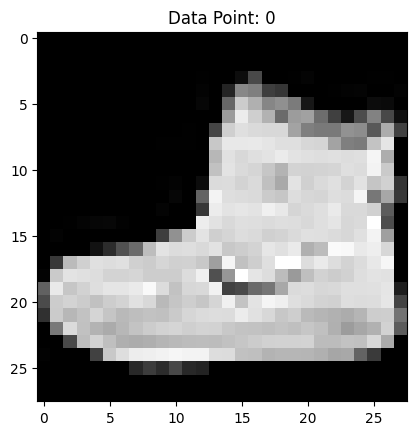

In [13]:
# Load the dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Prepare input
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
print("x_train shape: ", x_train.shape)
print("x_test shape: ", x_test.shape)

data_point_index = 0  # Choose the index of the data point you want to display

# Reshape the data point to a 28x28 image
image = x_train[data_point_index].reshape(28, 28)

# Display the image using matplotlib
plt.imshow(image, cmap='gray')  # Use 'gray' colormap for grayscale images
plt.title(f"Data Point: {data_point_index}")
plt.show()

# Normalize the pixel values to the range [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

## SLP

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

313/313 - 0s - 1ms/step - accuracy: 0.8476 - loss: 0.4408
Single-Layer Model - Test Loss: 0.44083431363105774, Test Accuracy: 0.847599983215332


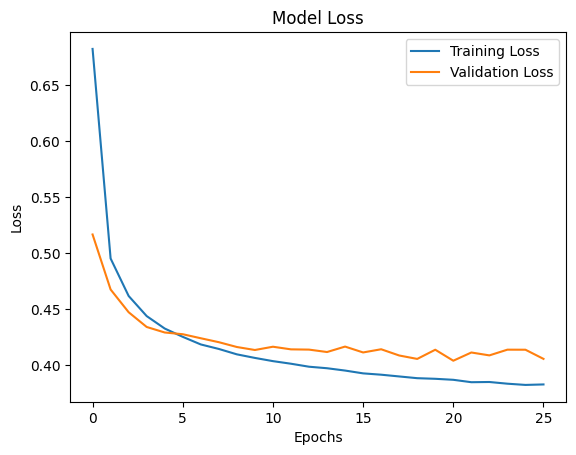

In [14]:
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=5,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity
)

# define model
model_slp = Sequential()
model_slp.add(Flatten(input_shape=(28,28)))
model_slp.add(Dense(10, activation='softmax'))

# compile the model
model_slp.compile(optimizer=RMSprop(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# fit the model
SLP_History = model_slp.fit(x_train, y_train, epochs=100, batch_size=100, validation_split=0.1, verbose=0, callbacks=[TqdmCallback(verbose=1), early_stopping])

# Evaluate the single-layer model
test_loss_single, test_acc_single = model_slp.evaluate(x_test, y_test, verbose=2)
print(f"Single-Layer Model - Test Loss: {test_loss_single}, Test Accuracy: {test_acc_single}")

# Plot training and validation loss
plt.plot(SLP_History.history['loss'], label='Training Loss')
plt.plot(SLP_History.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## MLP

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

313/313 - 1s - 3ms/step - accuracy: 0.8832 - loss: 0.3304
MLP Model - Test Loss: 0.33037546277046204, Test Accuracy: 0.8831999897956848


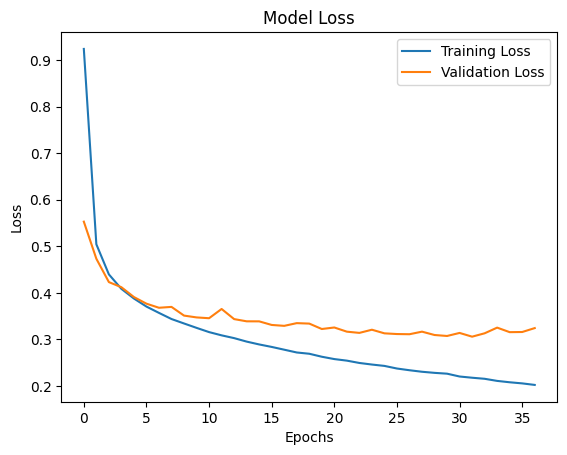

In [15]:
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=5,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity
)

# Multi-Layer Perceptron (MLP)
model_mlp = Sequential([
    Flatten(input_shape=(28, 28)),  # Flatten the 28x28 image to a 784-dimensional vector
    Dense(256, activation='relu'),  # First hidden layer with 256 units and ReLU activation
    Dense(64, activation='relu'),  # Second hidden layer with 128 units and ReLU activation
    Dense(32, activation='relu'),  # Second hidden layer with 128 units and ReLU activation
    Dense(10, activation='softmax')  # Output layer with 10 units (one for each class)
])

model_mlp.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the MLP model
history_mlp = model_mlp.fit(x_train, y_train, epochs=50, batch_size=100, validation_split=0.1, verbose=0, callbacks=[TqdmCallback(verbose=1), early_stopping])

# Evaluate the MLP model
test_loss_mlp, test_acc_mlp = model_mlp.evaluate(x_test, y_test, verbose=2)
print(f"MLP Model - Test Loss: {test_loss_mlp}, Test Accuracy: {test_acc_mlp}")

# Plot training and validation loss
plt.plot(history_mlp.history['loss'], label='Training Loss')
plt.plot(history_mlp.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [39]:
# prompt: Do a prediction from test set. Map output class to class name. Also display the image of the prediction

import numpy as np
# Assuming 'model_mlp' is your trained MLP model and 'x_test', 'y_test' are your test data
# Get predictions for the first 5 images
predictions = model_slp.predict(x_test[400:405])

# Class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


for i in range(5):
    predicted_class = np.argmax(predictions[i])
    predicted_class_name = class_names[predicted_class]

    actual_class = y_test[i]
    actual_class_name = class_names[actual_class]

    print(f"Image {i+1}:")
    print(f"  Predicted class: {predicted_class_name} ({predicted_class})")
    print(f"  Actual class: {actual_class_name} ({actual_class})")

    # # Display the image
    # plt.imshow(x_test[i], cmap='gray')
    # plt.title(f"Prediction: {predicted_class_name}, Actual: {actual_class_name}")
    # plt.show()

    print("------------")
    print("")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Image 1:
  Predicted class: T-shirt/top (0)
  Actual class: Ankle boot (9)
------------

Image 2:
  Predicted class: Ankle boot (9)
  Actual class: Pullover (2)
------------

Image 3:
  Predicted class: Sneaker (7)
  Actual class: Trouser (1)
------------

Image 4:
  Predicted class: T-shirt/top (0)
  Actual class: Trouser (1)
------------

Image 5:
  Predicted class: Coat (4)
  Actual class: Shirt (6)
------------

